In [1]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks, wiener, argrelextrema
from scipy import optimize

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

import os, copy, time

from nspyre import DataSink

In [246]:
df1 = pd.read_csv("Operation time.csv", index_col=0)

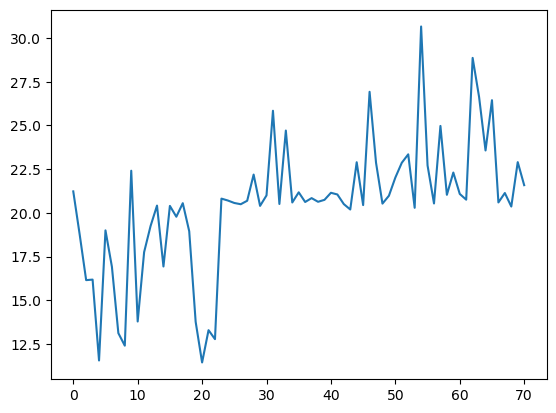

In [247]:
plt.plot(df1)

In [2]:
with DataSink("daq") as ds:
    ds.pop(timeout=None)

In [3]:
ds.data

[{Timestamp('2024-04-30 10:00:44.250009'): array([[4.58159124, 4.67314676, 4.74898526, ..., 4.48988311, 4.55839717,
          4.63377789],
         [4.85885189, 4.68108158, 4.86907559, ..., 4.37070833, 4.46745201,
          4.41511277],
         [4.80773339, 4.77233192, 4.66795862, ..., 4.22132023, 4.35453352,
          4.17294839]])},
 {Timestamp('2024-04-30 10:00:44.641951'): array([[4.63194678, 4.60951567, 4.57899716, ..., 2.80175176, 2.77947325,
          2.73659474],
         [4.52574236, 4.34354686, 4.57594531, ..., 2.51060518, 2.56859035,
          2.38868374],
         [4.30738243, 4.37467574, 4.16394543, ..., 2.06198309, 2.27759636,
          2.03848384]])},
 {Timestamp('2024-04-30 10:00:45.048058'): array([[ 2.86843471,  2.94000061,  2.8766747 , ...,  0.09659108,
          -0.09552293, -0.12634663],
         [ 2.52677999,  2.59697256,  2.49961852, ..., -0.38819544,
          -0.41642506, -0.28443251],
         [ 2.05023347,  2.18375195,  2.00201422, ..., -0.96316416,
        

In [81]:
def parsingData(inputData, dfData, samplingFrequency, timeStampList, DeltaT):
    ''' 
    Receiving a list of dictionaries with single key (a timestamp) and a value, 
    which is a list of 1 to 3 lists of voltages (one per channel). Each list has 
    around 1000 entries, but not necessarily exactly.
    The time stamps are expanded for each voltage separately. The values are extra-
    polated from the known sampling frequency.
    '''
    nloops = 0
    for entry in inputData:
        t0 = time.perf_counter_ns()
        # Looping over entries
        timestamp = list(entry.keys())[0]
        if timestamp not in timeStampList:
            nloops=nloops+1
            
            t1 = time.perf_counter_ns()
            # Data is coming in with typically only 1 new timestamp.
            # Timestamps that have already been processed in previous 
            # iterations are ignored.
            # New time stamp is appended to the list of processed timestamps
            timeStampList.append(timestamp)
            if len(timeStampList) > 1000:
                # To keep the list lookup reasonably fast, we remove old values
                timeStampList.pop(0)
            t2 = time.perf_counter_ns()
            # Transformig values into a data frame
            values = list(entry.values())[0]
            dfSubsetData = pd.DataFrame(values)
            # Generating timestamp values for each entry
            t3 = time.perf_counter_ns()
 
            end = timestamp
            dataLen = dfSubsetData.shape[1]
            start = end - pd.Timedelta(dataLen*1/samplingFrequency, unit="seconds")

            timeIndex = pd.date_range(start=start, end=end, periods=dataLen)
            t4 = time.perf_counter_ns()

            dfSubsetData = dfSubsetData.transpose()
            dfSubsetData.index = pd.DatetimeIndex(timeIndex)
            
            dfData = pd.concat([dfData, dfSubsetData])
            
            #################################################################################################
            # T6
            ############################
            t5 = time.perf_counter_ns()
            # Concatenating the data chunk to the main data frame.
            dfData.sort_index(inplace=True, ascending=True)
            t6 = time.perf_counter_ns()
            #################################################################################################
            
            # The upper bound of the data frame size (e.g. latest value + 1 second)
            lowerBound = dfData.index[0] - DeltaT
            # Truncate will remove all values that are over the upperBound value
            dfData = dfData.truncate(before=lowerBound)
            t7 = time.perf_counter_ns()

            # For debugging purposes
            #print(f"T1: {(t1 - t0)/1e6} ms, T2: {(t2 - t1)/1e6} ms, T3: {(t3-t3)/1e6} ms, T4: {(t4-t3)/1e6} ms, T5: {(t5-t4)/1e6} ms, T6: {(t6-t5)/1e6} ms, T7: {(t7-t6)/1e6} ms")

    return dfData

In [82]:
dfData

,0,1,2
2024-04-29 14:04:32.976679000,4.612873,4.505142,4.221931
2024-04-29 14:04:32.977079400,4.722587,4.382000,4.355754
2024-04-29 14:04:32.977479800,4.492019,4.513077,4.357738
2024-04-29 14:04:32.977880201,4.762413,4.356059,4.349956
2024-04-29 14:04:32.978280601,4.669790,4.546495,4.191717
...,...,...,...
2024-04-29 14:04:40.968192398,4.593951,4.377728,4.220710
2024-04-29 14:04:40.968592798,4.581744,4.417096,4.438917
2024-04-29 14:04:40.968993199,4.554430,4.433271,4.207129
2024-04-29 14:04:40.969393599,4.646596,4.577929,4.275796


In [83]:
dfData = pd.DataFrame({0: [], 1: [], 2: []})
dfData

,0,1,2


In [84]:
opTime = []
samplingFrequency = 2500
timeStampList = []

dfData = pd.DataFrame({0: [], 1: [], 2: []})
#dfData.index = [pd.Timestamp.fromtimestamp(0)]
# This is the size of the final data frame.
DeltaT = pd.Timedelta(1, "seconds")


dfData = parsingData(ds.data, dfData=dfData, samplingFrequency=samplingFrequency, timeStampList=timeStampList, DeltaT=DeltaT)

In [85]:
dfData

,0,1,2
2024-04-29 14:04:32.976679000,4.612873,4.505142,4.221931
2024-04-29 14:04:32.977079400,4.722587,4.382000,4.355754
2024-04-29 14:04:32.977479800,4.492019,4.513077,4.357738
2024-04-29 14:04:32.977880201,4.762413,4.356059,4.349956
2024-04-29 14:04:32.978280601,4.669790,4.546495,4.191717
...,...,...,...
2024-04-29 14:04:40.968192398,4.593951,4.377728,4.220710
2024-04-29 14:04:40.968592798,4.581744,4.417096,4.438917
2024-04-29 14:04:40.968993199,4.554430,4.433271,4.207129
2024-04-29 14:04:40.969393599,4.646596,4.577929,4.275796


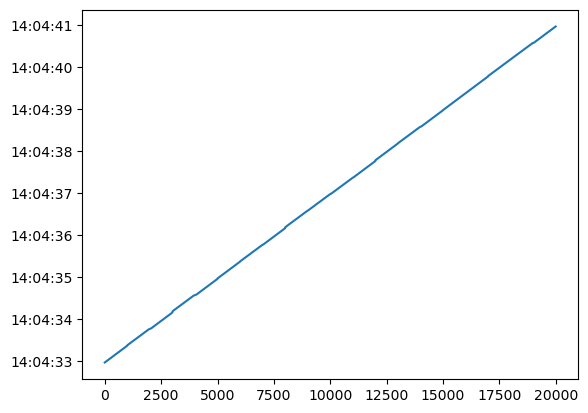

In [86]:
plt.plot(dfData.index)

(array([19835.6005787 , 19835.60058102, 19835.60058333, 19835.60058565,
        19835.60058796, 19835.60059028, 19835.60059259, 19835.60059491]),
 [Text(19835.600578703703, 0, '24:50.000000'),
  Text(19835.60058101852, 0, '24:50.200000'),
  Text(19835.600583333333, 0, '24:50.400000'),
  Text(19835.60058564815, 0, '24:50.600000'),
  Text(19835.600587962963, 0, '24:50.800000'),
  Text(19835.600590277776, 0, '24:51.000000'),
  Text(19835.600592592593, 0, '24:51.200000'),
  Text(19835.600594907406, 0, '24:51.400000')])

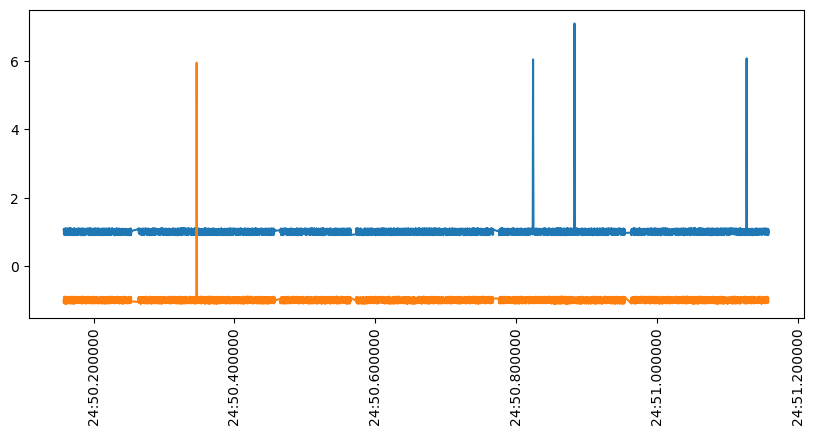

In [43]:
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(4)

plt.plot(dfData[0]+1)
plt.plot(dfData[1]-1)
plt.xticks(rotation=90)

In [132]:
threshold = 2
dfPosition = 4000

scores = np.array([])
maxPositions = []

lengthHalfMask = 5
mask = np.concatenate((np.repeat(False, lengthHalfMask), np.repeat(True, lengthHalfMask)))
#mask = np.concatenate((np.repeat(False, lengthHalfMask), np.repeat(True, lengthHalfMask)))
data3bool = dfData.iloc[:dfPosition,0] < threshold
for position in range(0, len(data3bool)-len(mask)):
    score = sum(data3bool[position:(position+len(mask))] == mask)
    scores = np.append(scores, score)  

In [135]:
peaks = argrelextrema(scores, comparator=np.greater)[0]
peaks = peaks + lengthHalfMask

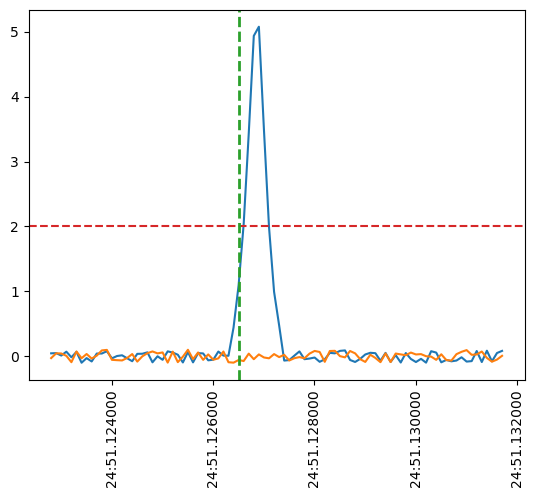

In [136]:
#plt.plot(dfData, label="DAQ signal")
plt.plot(dfData.iloc[260:350, :], label="DAQ signal")
plt.axhline(y=threshold, color='tab:red', linestyle='--', label="Peak detection threshold")
plt.xticks(rotation=90)
for peak in peaks:
    plt.axvline(x=dfData.index[peak], color='tab:green', linestyle='--', linewidth = 2, label="Peak detection performance")
    break

In [319]:
peakList = []
for channel in dfData:
    peaks, properties = find_peaks(dfData[channel], height=3, width=1)
    print(peaks)
    peakList.append(peaks)

[2497 3365]
[2412 3937]
[]


In [274]:
timestampList = []
for channel in dfData: 
    #print(list(dfData.iloc[peakList[channel],channel].index))
    timestamps = dfData.iloc[peakList[channel],channel].index
    timestamps = list((timestamps - pd.Timestamp("1970-01-01")) // pd.Timedelta('1ns'))
    timestampList.append(timestamps)

In [275]:
timestampList

[[1713955997753378250, 1713955997583650463],
 [1713955997761886758, 1713955997526393206],
 []]

In [273]:
timestamps - pd.Timestamp("1970-01-01")

TimedeltaIndex(['19837 days 10:53:17.753378250', '19837 days 10:53:17.583650463'], dtype='timedelta64[ns]', freq=None)

In [276]:
peakList

[array([2497, 3365], dtype=int64),
 array([2412, 3937], dtype=int64),
 array([], dtype=int64)]

In [ ]:
index = str(list((dfData.index - pd.Timestamp("1970-01-01")) // pd.Timedelta('1ns')))

In [281]:
arr1 = [np.array([]), np.array([]), np.array([])]
arr1 

[array([], dtype=float64), array([], dtype=float64), array([], dtype=float64)]

In [286]:
sum([len(array)>0 for array in peakList])

2

In [169]:
peaks, properties = find_peaks(dfData[1], height=3, width=1)
peaks

array([8174], dtype=int64)

In [170]:
peaks, properties = find_peaks(dfData[2], height=3, width=1)
peaks

array([], dtype=int64)

In [156]:
properties

{'peak_heights': array([5.07791326, 6.09854838, 5.04906755]),
 'prominences': array([5.177501  , 6.19854292, 5.14861716]),
 'left_bases': array([ 214, 2244, 2942], dtype=int64),
 'right_bases': array([2244, 3996, 3996], dtype=int64),
 'widths': array([4.34312144, 4.33134261, 4.39419722]),
 'width_heights': array([2.48916277, 2.99927692, 2.47475897]),
 'left_ips': array([ 306.33283826, 2711.33581256, 3512.30110371]),
 'right_ips': array([ 310.6759597 , 2715.66715517, 3516.69530094])}

In [160]:
int(properties["left_ips"][0])

306

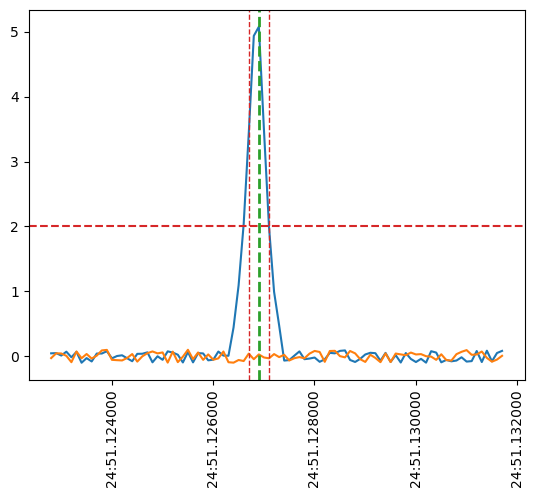

In [168]:
#plt.plot(dfData, label="DAQ signal")
plt.plot(dfData.iloc[260:350, :], label="DAQ signal")
plt.axhline(y=threshold, color='tab:red', linestyle='--', label="Peak detection threshold")
plt.xticks(rotation=90)

for n, peak in enumerate(peaks):
    plt.axvline(x=dfData.index[peak], color='tab:green', linestyle='--', linewidth = 2, label="Peak dtion performance")
    break

for peak in properties["left_ips"]:
    plt.axvline(x=dfData.index[int(peak)], color='tab:red', linestyle='--', linewidth = 1, label="Peak detection performance")
    break
    
for peak in properties["right_ips"]:
    plt.axvline(x=dfData.index[int(peak)], color='tab:red', linestyle='--', linewidth = 1, label="Peak detection performance")
    break

In [173]:
[10]*5

[10, 10, 10, 10, 10]

In [177]:
dfData.iloc[0:9,:]

,0,1,2
2024-04-22 14:24:51.157736000,-0.077346,0.043277,NaN
2024-04-22 14:24:51.157635899,0.069334,0.029188,NaN
2024-04-22 14:24:51.157535799,-0.055770,-0.017879,NaN
2024-04-22 14:24:51.157435699,0.014972,-0.060190,NaN
2024-04-22 14:24:51.157335599,0.006470,-0.037770,NaN
2024-04-22 14:24:51.157235499,0.086320,-0.053392,NaN
2024-04-22 14:24:51.157135399,-0.018381,-0.074621,NaN
2024-04-22 14:24:51.157035299,-0.061338,-0.056563,NaN
2024-04-22 14:24:51.156935199,-0.023357,-0.052088,NaN


In [179]:
if 2 >= 2:
    print("yes")
else:
    print("no")

yes


In [184]:
pd.Timestamp.as dfData.index

TypeError: sequence item 0: expected str instance, Timestamp found

In [187]:
idx1 = dfData.index[0]

Transforming time stamps into UNIX times

In [203]:
index = str(list((dfData.index - pd.Timestamp("1970-01-01")) // pd.Timedelta('1ns')))

In [213]:
t0 = time.perf_counter_ns()
index = str(list((dfData.index - pd.Timestamp("1970-01-01")) // pd.Timedelta('1ns')))
for column in dfData:
    str(list(dfData[column]))
t1 = time.perf_counter_ns()
print(f"Time elapsed {(t1 - t0)/1e6} ms")

Time elapsed 83.9168 ms


In [232]:
dfData1 = dfData.copy()
dfData1.index.name="timeIndex"

In [242]:
t0 = time.perf_counter_ns()
delta = pd.Timedelta(value=300, unit="microseconds")
dfData1.resample(delta).mean()
t1 = time.perf_counter_ns()
print(f"Time elapsed {(t1 - t0)/1e6} ms")

Time elapsed 9.3622 ms


In [244]:
str(time.time())

'1713943911.3451958'

In [299]:
peakList[0].add(1)

In [328]:
def timeFinder(offset, data):
    ch2Pos = data[1]
    error = 0
    for value in data[0]: 
        error = error + min([abs((value+offset)-x) for x in ch2Pos])

    return error 

In [329]:
def minimize(data): 
    res = optimize.minimize_scalar(timeFinder, 
                                   args=data, bracket=(3e8, 8e9), 
                                   method='Brent', 
                                   options={"disp": True, "xtol":1e-10, "maxiter":1e5})
    #print(f"Time : {res.x[0]/1e9} s")
    #print(f"[daqVelocityProcess] Result: {res.x/1e9} s")

    return res.x/1e9

In [330]:
timestampList

[[1713955997753378250, 1713955997583650463],
 [1713955997761886758, 1713955997526393206],
 []]

In [331]:
minimize(timestampList)


Optimization terminated successfully;
The returned value satisfies the termination criteria
(using xtol = 1e-10 )


-0.038274584171113867

array([[4.61287271, 4.72258675, 4.49201941, ..., 2.75704215, 2.74315622,
        2.98135319],
       [4.50514237, 4.38200018, 4.51307718, ..., 2.50236518, 2.5286111 ,
        2.62993255],
       [4.2219306 , 4.35575426, 4.35773797, ..., 2.08975494, 2.27423933,
        2.28766747]])

In [47]:
timestamp = list(ds.data[0].keys())[0]

end = timestamp
dataLen = ds.data[0][timestamp].shape[1]
start = end - pd.Timedelta(dataLen*1/samplingFrequency, unit="seconds")

timeIndex = pd.date_range(start=start, end=end, periods=dataLen)

start = end - pd.Timedelta(dataLen*1/samplingFrequency, unit="seconds")

timeIndex = pd.date_range(start=start, end=end, periods=dataLen)

df1 = pd.DataFrame(ds.data[0][timestamp])
df1 = df1.transpose()
df1.index = timeIndex

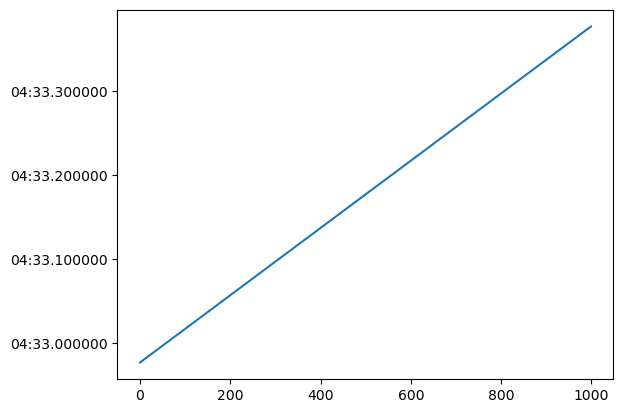

In [48]:
plt.plot(timeIndex)

DatetimeIndex([   '2024-04-29 14:04:32.976679',
               '2024-04-29 14:04:32.977079400',
               '2024-04-29 14:04:32.977479800',
               '2024-04-29 14:04:32.977880201',
               '2024-04-29 14:04:32.978280601',
               '2024-04-29 14:04:32.978681002',
               '2024-04-29 14:04:32.979081402',
               '2024-04-29 14:04:32.979481802',
               '2024-04-29 14:04:32.979882203',
               '2024-04-29 14:04:32.980282603',
               ...
               '2024-04-29 14:04:33.373075396',
               '2024-04-29 14:04:33.373475796',
               '2024-04-29 14:04:33.373876197',
               '2024-04-29 14:04:33.374276597',
               '2024-04-29 14:04:33.374676997',
               '2024-04-29 14:04:33.375077398',
               '2024-04-29 14:04:33.375477798',
               '2024-04-29 14:04:33.375878199',
               '2024-04-29 14:04:33.376278599',
                  '2024-04-29 14:04:33.376679'],
              dtype=

In [50]:
timestamp = list(ds.data[1].keys())[0]

end = timestamp
dataLen = ds.data[1][timestamp].shape[1]
start = end - pd.Timedelta(dataLen*1/samplingFrequency, unit="seconds")

timeIndex = pd.date_range(start=start, end=end, periods=dataLen)

start = end - pd.Timedelta(dataLen*1/samplingFrequency, unit="seconds")

timeIndex = pd.date_range(start=start, end=end, periods=dataLen)

df2 = pd.DataFrame(ds.data[1][timestamp])
df2 = df2.transpose()
df2.index = timeIndex

In [53]:
df3 = pd.concat([df1, df2])

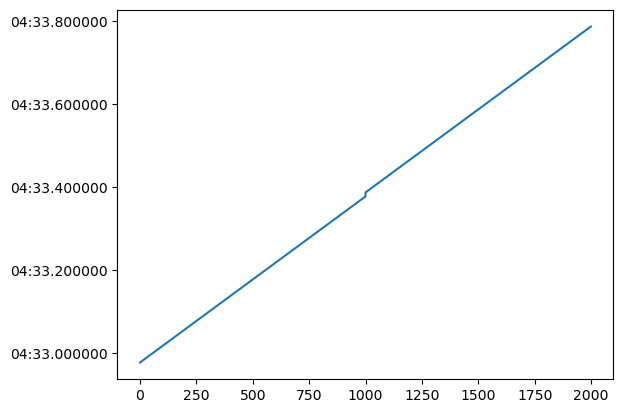

In [57]:
plt.plot(df3.index)

In [64]:
dfData = pd.DataFrame({0: [], 1: [], 2: []})
dfData = pd.concat([dfData, df1])
dfData = pd.concat([dfData, df2])

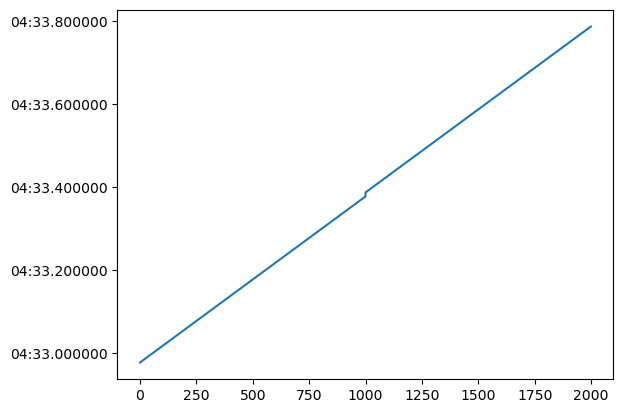

In [65]:
plt.plot(dfData.index)

1714471244250009000

In [40]:
output = []
output.append(str((list(ds.data[0].keys())[0] - pd.Timestamp("1970-01-01")) // pd.Timedelta('1ns')))

for channel in list(ds.data[0].values())[0]:
    channel = [str(np.float16(x)) for x in channel]
    channel = " ".join(channel)
    output.append(channel)

output = "|".join(output)

In [41]:
output

'1714471244250009000|4.582 4.67 4.75 4.6 4.64 4.75 4.49 4.67 4.67 4.55 4.59 4.723 4.566 4.62 4.67 4.54 4.746 4.58 4.734 4.496 4.72 4.504 4.633 4.71 4.656 4.516 4.69 4.715 4.51 4.59 4.54 4.62 4.605 4.63 4.55 4.727 4.652 4.54 4.58 4.516 4.594 4.51 4.742 4.58 4.754 4.715 4.676 4.62 4.766 4.63 4.56 4.74 4.582 4.723 4.56 4.543 4.527 4.55 4.61 4.652 4.707 4.64 4.676 4.543 4.703 4.8 4.742 4.566 4.72 4.76 4.727 4.637 4.566 4.78 4.684 4.668 4.77 4.73 4.633 4.67 4.566 4.62 4.69 4.832 4.723 4.793 4.543 4.633 4.582 4.6 4.676 4.645 4.785 4.613 4.582 4.69 4.555 4.605 4.832 4.656 4.64 4.812 4.586 4.652 4.82 4.742 4.797 4.598 4.684 4.637 4.75 4.574 4.65 4.805 4.58 4.64 4.566 4.65 4.75 4.82 4.684 4.582 4.59 4.82 4.742 4.7 4.69 4.582 4.58 4.82 4.785 4.785 4.676 4.86 4.844 4.637 4.844 4.836 4.703 4.715 4.71 4.844 4.777 4.664 4.758 4.68 4.703 4.777 4.594 4.66 4.598 4.8 4.836 4.86 4.805 4.855 4.71 4.645 4.69 4.766 4.75 4.867 4.715 4.594 4.625 4.598 4.85 4.805 4.867 4.746 4.777 4.62 4.62 4.723 4.63 4.824 4.

array([4.58159124, 4.67314676, 4.74898526, 4.60158086, 4.64201788,
       4.7482223 , 4.4901883 , 4.67131565, 4.67009491, 4.54985199,
       4.58861049, 4.72334971, 4.56816309, 4.62065493, 4.67101047,
       4.53794977, 4.74654378, 4.5762505 , 4.73601489, 4.49659719,
       4.71831416, 4.5025483 , 4.631489  , 4.71083712, 4.65620899,
       4.51643422, 4.69176305, 4.71495712, 4.51307718, 4.58891568,
       4.53993347, 4.61943419, 4.60448012, 4.63072604, 4.55092013,
       4.72808008, 4.65239418, 4.53947569, 4.57762383, 4.51734977,
       4.59425642, 4.51231422, 4.74044008, 4.5782342 , 4.7521897 ,
       4.71663564, 4.67741935, 4.62050233, 4.76485488, 4.62721641,
       4.55824458, 4.73921934, 4.58326975, 4.72319712, 4.56038087,
       4.54451125, 4.52772607, 4.5495468 , 4.60844752, 4.65269936,
       4.70778527, 4.63927122, 4.67390973, 4.5414594 , 4.70488601,
       4.79964599, 4.74028748, 4.56572161, 4.71709342, 4.75981933,
       4.72823267, 4.63789789, 4.56617939, 4.78164006, 4.68489